In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import matplotlib.pyplot as plt
import numpy as np
import pickle

In [2]:
# ── reproducibility ──────────────────────────────────────────────────────────
torch.manual_seed(42)
np.random.seed(42)

In [3]:
# ── model (identical to teammate's baseline) ──────────────────────────────────
class AblationMLP(nn.Module):
    def __init__(self, use_dropout=False, use_batchnorm=False, dropout_p=0.5, hidden_sizes=None):
        super(AblationMLP, self).__init__()
        if hidden_sizes is None:
            hidden_sizes = [1024, 512, 256]
        self.flatten = nn.Flatten()

        self.fc1 = nn.Linear(3072, hidden_sizes[0])
        self.bn1 = nn.BatchNorm1d(hidden_sizes[0]) if use_batchnorm else None
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout_p) if use_dropout else None

        self.fc2 = nn.Linear(hidden_sizes[0], hidden_sizes[1])
        self.bn2 = nn.BatchNorm1d(hidden_sizes[1]) if use_batchnorm else None
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout_p) if use_dropout else None

        self.fc3 = nn.Linear(hidden_sizes[1], hidden_sizes[2])
        self.bn3 = nn.BatchNorm1d(hidden_sizes[2]) if use_batchnorm else None
        self.relu3 = nn.ReLU()
        self.dropout3 = nn.Dropout(dropout_p) if use_dropout else None

        self.fc4 = nn.Linear(hidden_sizes[2], 10)

        self.use_dropout = use_dropout
        self.use_batchnorm = use_batchnorm

    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        if self.use_batchnorm: x = self.bn1(x)
        x = self.relu1(x)
        if self.use_dropout:   x = self.dropout1(x)
        x = self.fc2(x)
        if self.use_batchnorm: x = self.bn2(x)
        x = self.relu2(x)
        if self.use_dropout:   x = self.dropout2(x)
        x = self.fc3(x)
        if self.use_batchnorm: x = self.bn3(x)
        x = self.relu3(x)
        if self.use_dropout:   x = self.dropout3(x)
        x = self.fc4(x)
        return x

    def get_linear_weights(self):
        return [self.fc1.weight, self.fc2.weight, self.fc3.weight, self.fc4.weight]

    def get_all_weights_flat(self):
        return torch.cat([w.data.view(-1) for w in self.get_linear_weights()]).cpu().numpy()


In [4]:
# ── data (identical 3-way split to teammate's baseline) ───────────────────────
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

full_train_dataset = datasets.CIFAR10(root='./data', train=True,  download=True, transform=transform)
full_test_dataset  = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

torch.manual_seed(42)
subset_train, _ = torch.utils.data.random_split(
    full_train_dataset, [20000, 30000],
    generator=torch.Generator().manual_seed(42))

train_dataset, val_dataset = torch.utils.data.random_split(
    subset_train, [15000, 5000],
    generator=torch.Generator().manual_seed(42))

test_dataset = full_test_dataset

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=128, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = torch.utils.data.DataLoader(val_dataset,   batch_size=128, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = torch.utils.data.DataLoader(test_dataset,  batch_size=128, shuffle=False, num_workers=2, pin_memory=True)

print(f"Training set size  : {len(train_dataset):,}")
print(f"Validation set size: {len(val_dataset):,}")
print(f"Test set size      : {len(test_dataset):,}")


100%|██████████| 170M/170M [00:03<00:00, 43.0MB/s]


Training set size  : 15,000
Validation set size: 5,000
Test set size      : 10,000


In [5]:
# ── device & hyperparameters ──────────────────────────────────────────────────
device          = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
MAX_EPOCHS      = 50
LEARNING_RATE   = 0.01
L1_LAMBDA       = 1e-4
L2_WEIGHT_DECAY = 1e-3

print(f"Device: {device}")

Device: cuda


In [6]:
# ── helpers ───────────────────────────────────────────────────────────────────
def l1_penalty(model):
    return sum(w.abs().sum() for w in model.get_linear_weights())


def evaluate(model, dataloader):
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total   += labels.size(0)
            correct += (predicted == labels).sum().item()
    model.train()
    return 100 * correct / total


def compute_loss(model, dataloader, loss_fn):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            total_loss += loss_fn(outputs, labels).item()
    model.train()
    return total_loss / len(dataloader)


def train_one_run(label, use_l1=False, use_l2=False, use_adam=False):
    print(f"\n{'='*60}")
    print(f"  Training: {label}")
    print(f"{'='*60}")

    # identical init for every run
    torch.manual_seed(42)
    torch.cuda.manual_seed(42)
    model   = AblationMLP(use_dropout=False, use_batchnorm=False,
                          hidden_sizes=[1024, 512, 256]).to(device)
    loss_fn = nn.CrossEntropyLoss()

    wd = L2_WEIGHT_DECAY if use_l2 else 0.0
    if use_adam:
        optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=wd)
    else:
        optimizer = optim.SGD(model.parameters(), lr=LEARNING_RATE, weight_decay=wd)

    # capture initial weights
    initial_weights = model.get_all_weights_flat().copy()

    train_losses, val_losses = [], []
    train_accs,   val_accs   = [], []
    l1_norms,     l2_norms   = [], []

    for epoch in range(MAX_EPOCHS):
        # ── training step ──
        model.train()
        epoch_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss    = loss_fn(outputs, labels)
            if use_l1:
                loss = loss + L1_LAMBDA * l1_penalty(model)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        avg_train_loss = epoch_loss / len(train_loader)

        # ── evaluation (train + val only during training, matching teammate) ──
        train_acc  = evaluate(model, train_loader)
        val_loss   = compute_loss(model, val_loader, loss_fn)
        val_acc    = evaluate(model, val_loader)

        # ── weight norms ──
        with torch.no_grad():
            wcat = torch.cat([w.data.view(-1) for w in model.get_linear_weights()])
            l1_norms.append(wcat.abs().sum().item())
            l2_norms.append(wcat.pow(2).sum().sqrt().item())

        train_losses.append(avg_train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        print(f"  Epoch {epoch+1:2d}/{MAX_EPOCHS} | "
              f"Train Loss: {avg_train_loss:.4f} | Val Loss: {val_loss:.4f} | "
              f"Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}% | "
              f"L1‑norm: {l1_norms[-1]:.1f}")

    # ── final test evaluation (only once, after all training) ──
    test_acc  = evaluate(model, test_loader)
    test_loss = compute_loss(model, test_loader, loss_fn)
    final_weights = model.get_all_weights_flat().copy()

    gap = train_accs[-1] - val_accs[-1]
    print(f"\n  Final Train Acc : {train_accs[-1]:.2f}%")
    print(f"  Final Val Acc   : {val_accs[-1]:.2f}%")
    print(f"  Final Test Acc  : {test_acc:.2f}%")
    print(f"  Generalization Gap (Train - Val): {gap:.2f}%")

    return {
        "label":           label,
        "train_losses":    train_losses,
        "val_losses":      val_losses,
        "train_accs":      train_accs,
        "val_accs":        val_accs,
        "test_acc":        test_acc,
        "test_loss":       test_loss,
        "l1_norms":        l1_norms,
        "l2_norms":        l2_norms,
        "initial_weights": initial_weights,
        "final_weights":   final_weights,
    }

In [7]:
# ── Cell 1: run baseline ──────────────────────────────────────────────────────
results_baseline = train_one_run("Baseline (No Regularization)", use_l1=False, use_l2=False)
with open('all_results.pkl', 'wb') as f:
    pickle.dump({'baseline': results_baseline}, f)
print("baseline saved!")


  Training: Baseline (No Regularization)
  Epoch  1/50 | Train Loss: 2.2642 | Val Loss: 2.2163 | Train Acc: 25.75% | Val Acc: 24.68% | L1‑norm: 39547.1
  Epoch  2/50 | Train Loss: 2.1429 | Val Loss: 2.0868 | Train Acc: 27.87% | Val Acc: 26.50% | L1‑norm: 39566.9
  Epoch  3/50 | Train Loss: 2.0172 | Val Loss: 1.9776 | Train Acc: 31.79% | Val Acc: 29.74% | L1‑norm: 39590.7
  Epoch  4/50 | Train Loss: 1.9189 | Val Loss: 1.8974 | Train Acc: 33.99% | Val Acc: 31.64% | L1‑norm: 39614.9
  Epoch  5/50 | Train Loss: 1.8416 | Val Loss: 1.8346 | Train Acc: 36.55% | Val Acc: 33.90% | L1‑norm: 39637.9
  Epoch  6/50 | Train Loss: 1.7793 | Val Loss: 1.7913 | Train Acc: 38.13% | Val Acc: 35.26% | L1‑norm: 39660.5
  Epoch  7/50 | Train Loss: 1.7295 | Val Loss: 1.7554 | Train Acc: 40.09% | Val Acc: 37.02% | L1‑norm: 39681.7
  Epoch  8/50 | Train Loss: 1.6807 | Val Loss: 1.7069 | Train Acc: 42.28% | Val Acc: 38.50% | L1‑norm: 39703.7
  Epoch  9/50 | Train Loss: 1.6359 | Val Loss: 1.6741 | Train Acc: 43.

In [8]:
# ── Cell 2: run L1 ───────────────────────────────────────────────────────────
results_l1 = train_one_run("L1 Regularization", use_l1=True, use_l2=False)
with open('all_results.pkl', 'rb') as f: saved = pickle.load(f)
saved['l1'] = results_l1
with open('all_results.pkl', 'wb') as f: pickle.dump(saved, f)
print("L1 saved!")


  Training: L1 Regularization
  Epoch  1/50 | Train Loss: 6.1969 | Val Loss: 2.2182 | Train Acc: 25.74% | Val Acc: 24.66% | L1‑norm: 39100.0
  Epoch  2/50 | Train Loss: 6.0357 | Val Loss: 2.0924 | Train Acc: 27.69% | Val Acc: 26.38% | L1‑norm: 38676.4
  Epoch  3/50 | Train Loss: 5.8714 | Val Loss: 1.9857 | Train Acc: 31.47% | Val Acc: 29.56% | L1‑norm: 38260.3
  Epoch  4/50 | Train Loss: 5.7343 | Val Loss: 1.9073 | Train Acc: 33.59% | Val Acc: 31.34% | L1‑norm: 37847.8
  Epoch  5/50 | Train Loss: 5.6181 | Val Loss: 1.8460 | Train Acc: 36.01% | Val Acc: 33.34% | L1‑norm: 37436.9
  Epoch  6/50 | Train Loss: 5.5168 | Val Loss: 1.8037 | Train Acc: 37.54% | Val Acc: 34.92% | L1‑norm: 37028.8
  Epoch  7/50 | Train Loss: 5.4286 | Val Loss: 1.7681 | Train Acc: 39.61% | Val Acc: 36.36% | L1‑norm: 36622.6
  Epoch  8/50 | Train Loss: 5.3416 | Val Loss: 1.7223 | Train Acc: 41.55% | Val Acc: 37.64% | L1‑norm: 36219.4
  Epoch  9/50 | Train Loss: 5.2587 | Val Loss: 1.6898 | Train Acc: 42.92% | Val A

In [9]:
# ── Cell 3: run L2 ───────────────────────────────────────────────────────────
results_l2 = train_one_run("L2 Regularization (SGD)", use_l1=False, use_l2=True, use_adam=False)
with open('all_results.pkl', 'rb') as f: saved = pickle.load(f)
saved['l2'] = results_l2
with open('all_results.pkl', 'wb') as f: pickle.dump(saved, f)
print("L2 saved!")


  Training: L2 Regularization (SGD)
  Epoch  1/50 | Train Loss: 2.2643 | Val Loss: 2.2168 | Train Acc: 25.74% | Val Acc: 24.68% | L1‑norm: 39500.4
  Epoch  2/50 | Train Loss: 2.1438 | Val Loss: 2.0881 | Train Acc: 27.83% | Val Acc: 26.48% | L1‑norm: 39473.6
  Epoch  3/50 | Train Loss: 2.0188 | Val Loss: 1.9795 | Train Acc: 31.70% | Val Acc: 29.68% | L1‑norm: 39450.9
  Epoch  4/50 | Train Loss: 1.9212 | Val Loss: 1.8997 | Train Acc: 33.89% | Val Acc: 31.56% | L1‑norm: 39428.7
  Epoch  5/50 | Train Loss: 1.8444 | Val Loss: 1.8372 | Train Acc: 36.44% | Val Acc: 33.72% | L1‑norm: 39405.3
  Epoch  6/50 | Train Loss: 1.7825 | Val Loss: 1.7942 | Train Acc: 37.99% | Val Acc: 35.12% | L1‑norm: 39381.7
  Epoch  7/50 | Train Loss: 1.7333 | Val Loss: 1.7582 | Train Acc: 39.95% | Val Acc: 36.76% | L1‑norm: 39356.7
  Epoch  8/50 | Train Loss: 1.6849 | Val Loss: 1.7103 | Train Acc: 42.14% | Val Acc: 38.32% | L1‑norm: 39332.6
  Epoch  9/50 | Train Loss: 1.6406 | Val Loss: 1.6776 | Train Acc: 43.54% |

In [10]:
# ── Cell 4: restore all results ───────────────────────────────────────────────
with open('all_results.pkl', 'rb') as f: saved = pickle.load(f)
results_baseline = saved['baseline']
results_l1       = saved['l1']
results_l2       = saved['l2']
print("all results loaded!")

all_results = [results_baseline, results_l1, results_l2]
epochs      = range(1, MAX_EPOCHS + 1)
COLORS      = {
    "Baseline (No Regularization)": "#e74c3c",
    "L1 Regularization":            "#2ecc71",
    "L2 Regularization (SGD)":      "#3498db"
}

all results loaded!


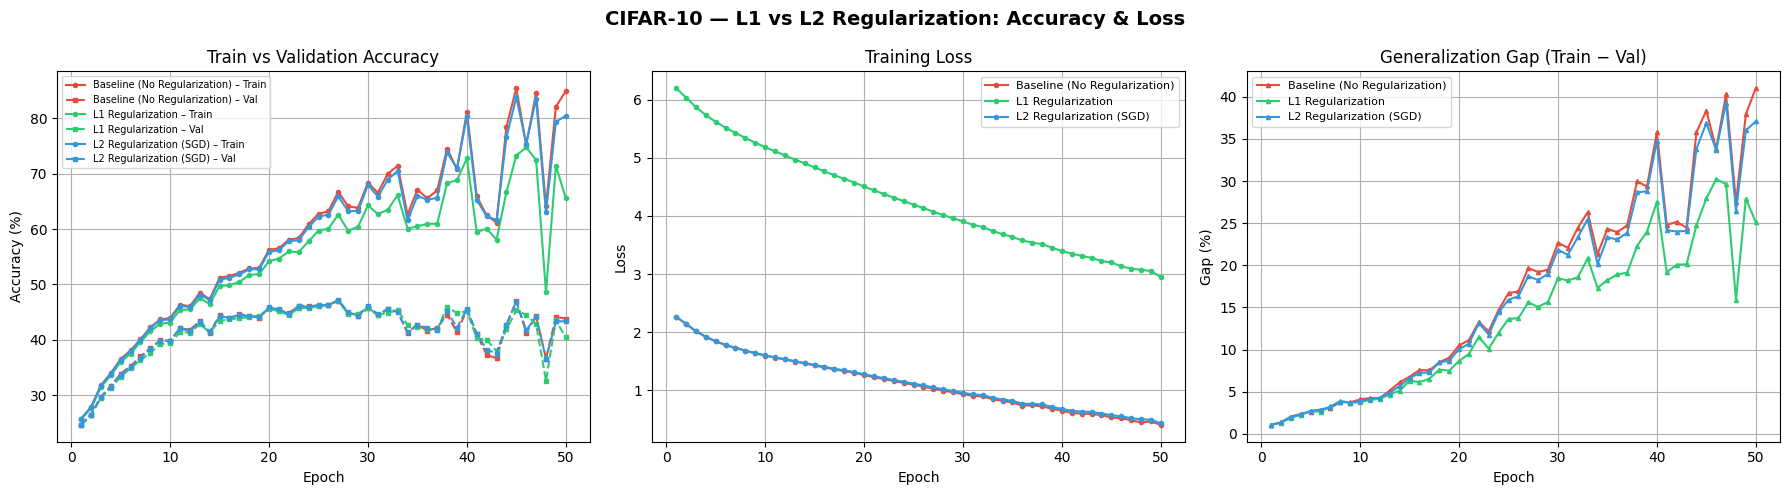

In [11]:
# ── Figure 1 — Train/Val accuracy, loss, generalization gap ───────────────────
fig1, axes1 = plt.subplots(1, 3, figsize=(18, 5))
fig1.suptitle("CIFAR-10 — L1 vs L2 Regularization: Accuracy & Loss", fontsize=14, fontweight='bold')

for r in all_results:
    c = COLORS[r["label"]]
    axes1[0].plot(epochs, r["train_accs"], linestyle='-',  marker='o', color=c,
                  label=f'{r["label"]} – Train', linewidth=1.5, markersize=3)
    axes1[0].plot(epochs, r["val_accs"],   linestyle='--', marker='s', color=c,
                  label=f'{r["label"]} – Val',   linewidth=1.5, markersize=3)
axes1[0].set_title("Train vs Validation Accuracy")
axes1[0].set_xlabel("Epoch"); axes1[0].set_ylabel("Accuracy (%)")
axes1[0].legend(fontsize=7); axes1[0].grid(True)

for r in all_results:
    axes1[1].plot(epochs, r["train_losses"], marker='o', color=COLORS[r["label"]],
                  label=r["label"], linewidth=1.5, markersize=3)
axes1[1].set_title("Training Loss")
axes1[1].set_xlabel("Epoch"); axes1[1].set_ylabel("Loss")
axes1[1].legend(fontsize=8); axes1[1].grid(True)

for r in all_results:
    gap = [tr - v for tr, v in zip(r["train_accs"], r["val_accs"])]
    axes1[2].plot(epochs, gap, marker='^', color=COLORS[r["label"]],
                  label=r["label"], linewidth=1.5, markersize=3)
axes1[2].set_title("Generalization Gap (Train − Val)")
axes1[2].set_xlabel("Epoch"); axes1[2].set_ylabel("Gap (%)")
axes1[2].legend(fontsize=8); axes1[2].grid(True)

plt.tight_layout()
plt.savefig("fig1_accuracy_loss.png", dpi=150, bbox_inches='tight')
plt.show()

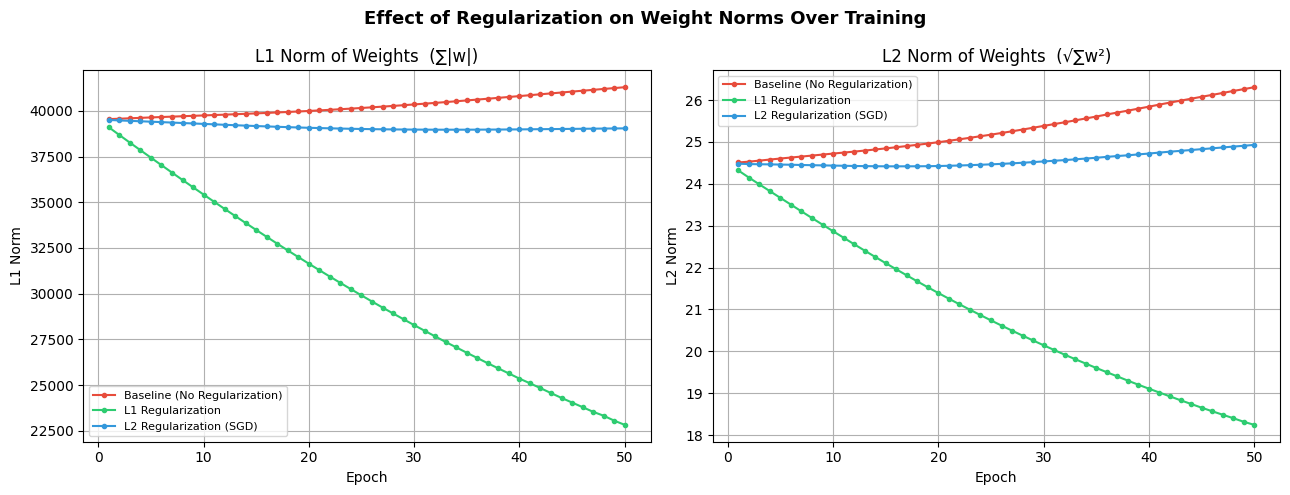

In [12]:
# ── Figure 2 — Weight norm evolution ─────────────────────────────────────────
fig2, axes2 = plt.subplots(1, 2, figsize=(13, 5))
fig2.suptitle("Effect of Regularization on Weight Norms Over Training", fontsize=13, fontweight='bold')

for r in all_results:
    c = COLORS[r["label"]]
    axes2[0].plot(epochs, r["l1_norms"], marker='o', color=c,
                  label=r["label"], linewidth=1.5, markersize=3)
    axes2[1].plot(epochs, r["l2_norms"], marker='o', color=c,
                  label=r["label"], linewidth=1.5, markersize=3)

axes2[0].set_title("L1 Norm of Weights  (∑|w|)")
axes2[0].set_xlabel("Epoch"); axes2[0].set_ylabel("L1 Norm")
axes2[0].legend(fontsize=8); axes2[0].grid(True)

axes2[1].set_title("L2 Norm of Weights  (√∑w²)")
axes2[1].set_xlabel("Epoch"); axes2[1].set_ylabel("L2 Norm")
axes2[1].legend(fontsize=8); axes2[1].grid(True)

plt.tight_layout()
plt.savefig("fig2_weight_norms.png", dpi=150, bbox_inches='tight')
plt.show()


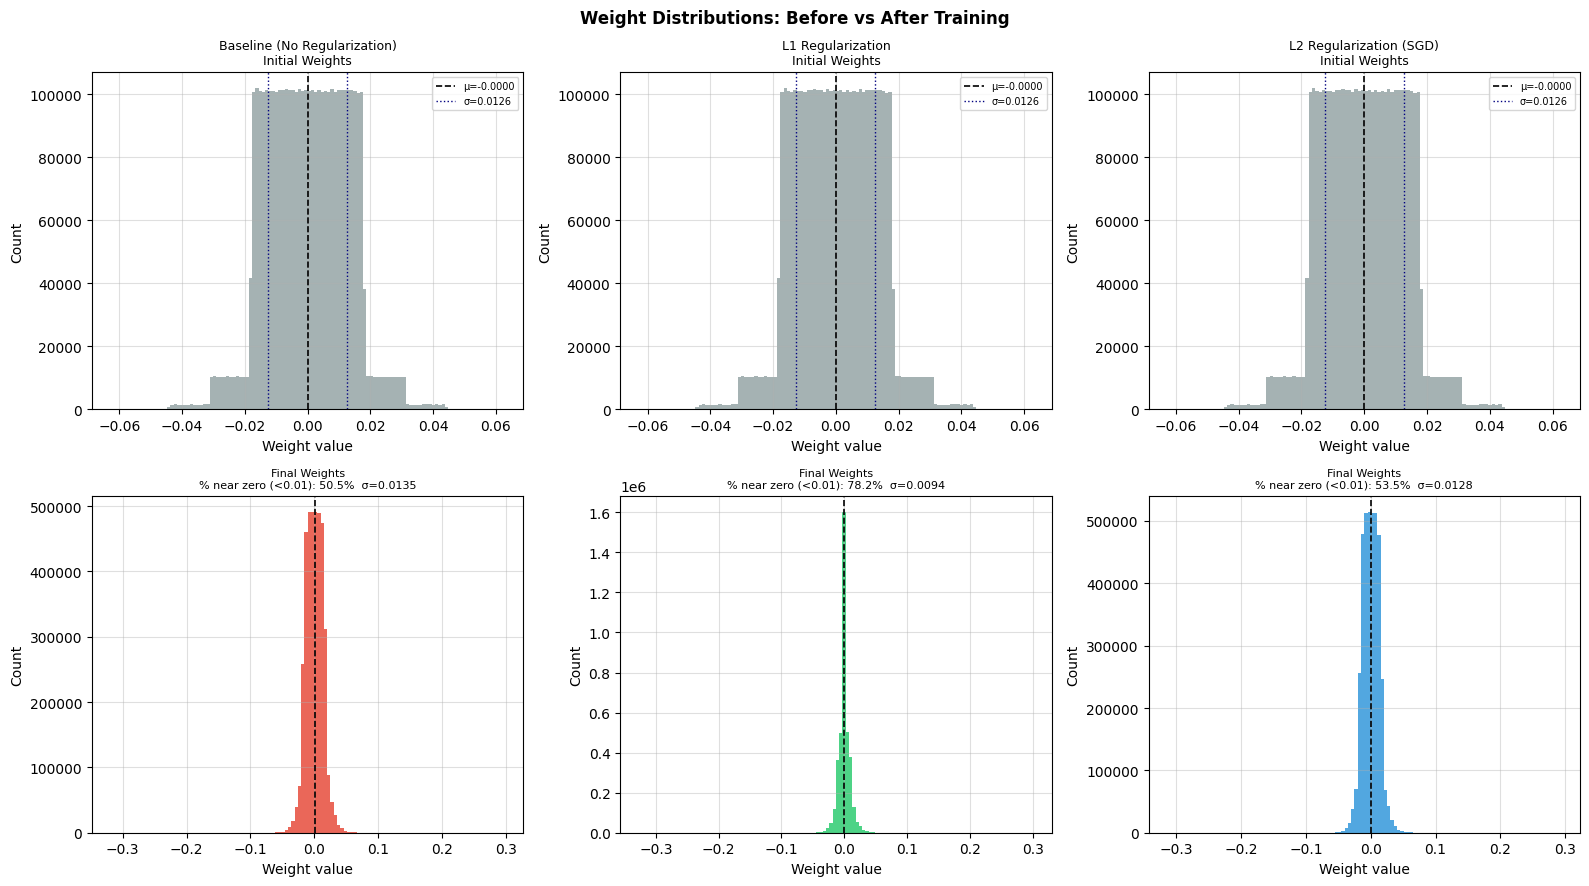

In [13]:
# ── Figure 3 — Weight histograms: initial vs final ────────────────────────────
fig3, axes3 = plt.subplots(2, 3, figsize=(16, 9))
fig3.suptitle("Weight Distributions: Before vs After Training", fontsize=12, fontweight='bold')

BINS = 120
for col, r in enumerate(all_results):
    c = COLORS[r["label"]]
    iw = r["initial_weights"]
    fw = r["final_weights"]

    # initial
    axes3[0, col].hist(iw, bins=BINS, color='#95a5a6', edgecolor='none', alpha=0.85)
    axes3[0, col].set_title(f"{r['label']}\nInitial Weights", fontsize=9)
    axes3[0, col].axvline(iw.mean(), color='black', linestyle='--', linewidth=1.2,
                           label=f'μ={iw.mean():.4f}')
    axes3[0, col].axvline(iw.mean()+iw.std(), color='navy', linestyle=':', linewidth=1,
                           label=f'σ={iw.std():.4f}')
    axes3[0, col].axvline(iw.mean()-iw.std(), color='navy', linestyle=':', linewidth=1)
    axes3[0, col].set_xlabel("Weight value"); axes3[0, col].set_ylabel("Count")
    axes3[0, col].legend(fontsize=7); axes3[0, col].grid(True, alpha=0.4)

    # final
    axes3[1, col].hist(fw, bins=BINS, color=c, edgecolor='none', alpha=0.85)
    axes3[1, col].set_title(
        f"Final Weights\n% near zero (<0.01): {100*(np.abs(fw)<0.01).mean():.1f}%  "
        f"σ={fw.std():.4f}", fontsize=8)
    axes3[1, col].axvline(fw.mean(), color='black', linestyle='--', linewidth=1.2)
    axes3[1, col].set_xlabel("Weight value"); axes3[1, col].set_ylabel("Count")
    axes3[1, col].grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig("fig3_weight_histograms.png", dpi=150, bbox_inches='tight')
plt.show()

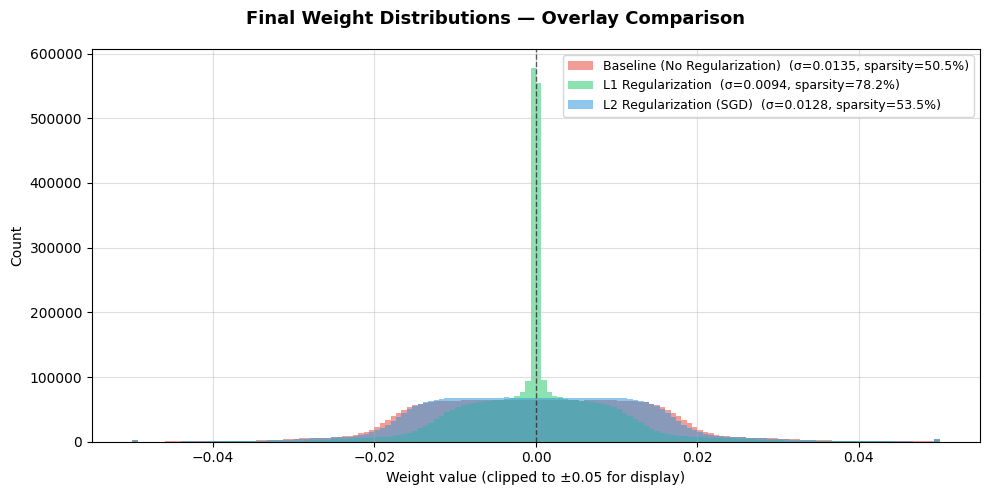

In [14]:
# ── Figure 4 — Final weight distribution overlay ──────────────────────────────
fig4, ax4 = plt.subplots(figsize=(10, 5))
fig4.suptitle("Final Weight Distributions — Overlay Comparison", fontsize=13, fontweight='bold')

for r in all_results:
    fw = r["final_weights"]
    clipped = np.clip(fw, -0.05, 0.05)
    ax4.hist(clipped, bins=150, alpha=0.55, color=COLORS[r["label"]],
             label=f'{r["label"]}  (σ={fw.std():.4f}, '
                   f'sparsity={100*(np.abs(fw)<0.01).mean():.1f}%)',
             edgecolor='none')

ax4.axvline(0, color='black', linewidth=1.0, linestyle='--', alpha=0.6)
ax4.set_xlabel("Weight value (clipped to ±0.05 for display)")
ax4.set_ylabel("Count")
ax4.legend(fontsize=9)
ax4.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig("fig4_weight_overlay.png", dpi=150, bbox_inches='tight')
plt.show()

In [16]:
# ── Summary table ─────────────────────────────────────────────────────────────
print("\n" + "="*75)
print(f"{'Model':<30} {'Train Acc':>10} {'Val Acc':>10} {'Test Acc':>10} {'Gap':>8}")
print("-"*75)
for r in all_results:
    print(f"{r['label']:<30} "
          f"{r['train_accs'][-1]:>9.2f}% "
          f"{r['val_accs'][-1]:>9.2f}% "
          f"{r['test_acc']:>9.2f}% "
          f"{r['train_accs'][-1]-r['val_accs'][-1]:>7.2f}%")
print("="*75)
print(f"\nL1 sparsity (|w|<0.01): "
      f"Baseline {100*(np.abs(results_baseline['final_weights'])<0.01).mean():.1f}% | "
      f"L1 {100*(np.abs(results_l1['final_weights'])<0.01).mean():.1f}% | "
      f"L2 {100*(np.abs(results_l2['final_weights'])<0.01).mean():.1f}%")


Model                           Train Acc    Val Acc   Test Acc      Gap
---------------------------------------------------------------------------
Baseline (No Regularization)       84.87%     43.84%     45.37%   41.03%
L1 Regularization                  65.58%     40.46%     41.40%   25.12%
L2 Regularization (SGD)            80.43%     43.36%     44.67%   37.07%

L1 sparsity (|w|<0.01): Baseline 50.5% | L1 78.2% | L2 53.5%


In [17]:
L2_WEIGHT_DECAY = 5e-3  # 5x stronger than current 1e-3

In [18]:
results_l2_strong = train_one_run("L2 Regularization (SGD - Strong)", use_l1=False, use_l2=True, use_adam=False)

# save separately so you don't overwrite existing results
with open('all_results.pkl', 'rb') as f: saved = pickle.load(f)
saved['l2_strong'] = results_l2_strong
with open('all_results.pkl', 'wb') as f: pickle.dump(saved, f)
print("saved!")


  Training: L2 Regularization (SGD - Strong)
  Epoch  1/50 | Train Loss: 2.2649 | Val Loss: 2.2185 | Train Acc: 25.69% | Val Acc: 24.70% | L1‑norm: 39314.4
  Epoch  2/50 | Train Loss: 2.1473 | Val Loss: 2.0931 | Train Acc: 27.63% | Val Acc: 26.42% | L1‑norm: 39102.7
  Epoch  3/50 | Train Loss: 2.0254 | Val Loss: 1.9868 | Train Acc: 31.43% | Val Acc: 29.64% | L1‑norm: 38896.6
  Epoch  4/50 | Train Loss: 1.9301 | Val Loss: 1.9088 | Train Acc: 33.46% | Val Acc: 31.32% | L1‑norm: 38692.4
  Epoch  5/50 | Train Loss: 1.8553 | Val Loss: 1.8475 | Train Acc: 35.97% | Val Acc: 33.06% | L1‑norm: 38488.6
  Epoch  6/50 | Train Loss: 1.7952 | Val Loss: 1.8052 | Train Acc: 37.41% | Val Acc: 34.94% | L1‑norm: 38285.9
  Epoch  7/50 | Train Loss: 1.7479 | Val Loss: 1.7697 | Train Acc: 39.49% | Val Acc: 36.22% | L1‑norm: 38083.1
  Epoch  8/50 | Train Loss: 1.7015 | Val Loss: 1.7241 | Train Acc: 41.35% | Val Acc: 37.68% | L1‑norm: 37882.5
  Epoch  9/50 | Train Loss: 1.6590 | Val Loss: 1.6917 | Train Acc:

In [19]:
# reload and swap
with open('all_results.pkl', 'rb') as f: saved = pickle.load(f)
results_l2 = saved['l2_strong']  # use strong instead

all_results = [results_baseline, results_l1, results_l2]
COLORS = {
    "Baseline (No Regularization)":    "#e74c3c",
    "L1 Regularization":               "#2ecc71",
    "L2 Regularization (SGD - Strong)":"#3498db"
}

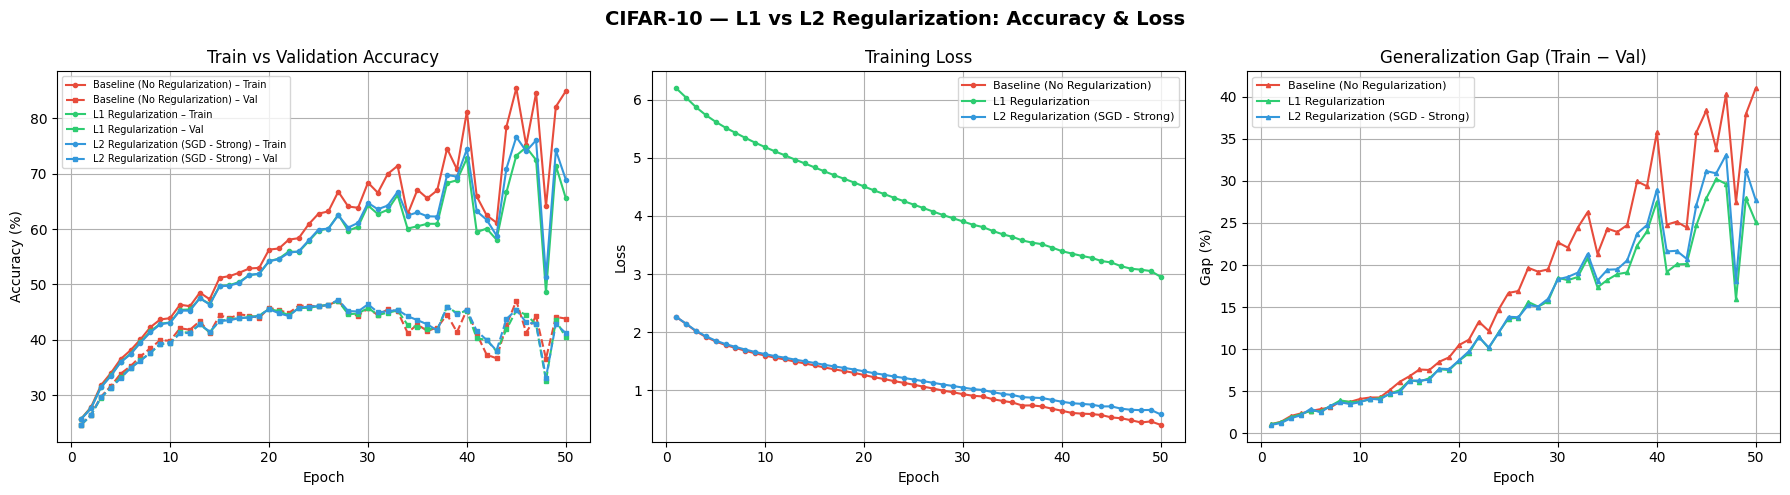

In [20]:
# ── Figure 1 — Train/Val accuracy, loss, generalization gap ───────────────────
fig1, axes1 = plt.subplots(1, 3, figsize=(18, 5))
fig1.suptitle("CIFAR-10 — L1 vs L2 Regularization: Accuracy & Loss", fontsize=14, fontweight='bold')

for r in all_results:
    c = COLORS[r["label"]]
    axes1[0].plot(epochs, r["train_accs"], linestyle='-',  marker='o', color=c,
                  label=f'{r["label"]} – Train', linewidth=1.5, markersize=3)
    axes1[0].plot(epochs, r["val_accs"],   linestyle='--', marker='s', color=c,
                  label=f'{r["label"]} – Val',   linewidth=1.5, markersize=3)
axes1[0].set_title("Train vs Validation Accuracy")
axes1[0].set_xlabel("Epoch"); axes1[0].set_ylabel("Accuracy (%)")
axes1[0].legend(fontsize=7); axes1[0].grid(True)

for r in all_results:
    axes1[1].plot(epochs, r["train_losses"], marker='o', color=COLORS[r["label"]],
                  label=r["label"], linewidth=1.5, markersize=3)
axes1[1].set_title("Training Loss")
axes1[1].set_xlabel("Epoch"); axes1[1].set_ylabel("Loss")
axes1[1].legend(fontsize=8); axes1[1].grid(True)

for r in all_results:
    gap = [tr - v for tr, v in zip(r["train_accs"], r["val_accs"])]
    axes1[2].plot(epochs, gap, marker='^', color=COLORS[r["label"]],
                  label=r["label"], linewidth=1.5, markersize=3)
axes1[2].set_title("Generalization Gap (Train − Val)")
axes1[2].set_xlabel("Epoch"); axes1[2].set_ylabel("Gap (%)")
axes1[2].legend(fontsize=8); axes1[2].grid(True)

plt.tight_layout()
plt.savefig("fig1_accuracy_loss.png", dpi=150, bbox_inches='tight')
plt.show()

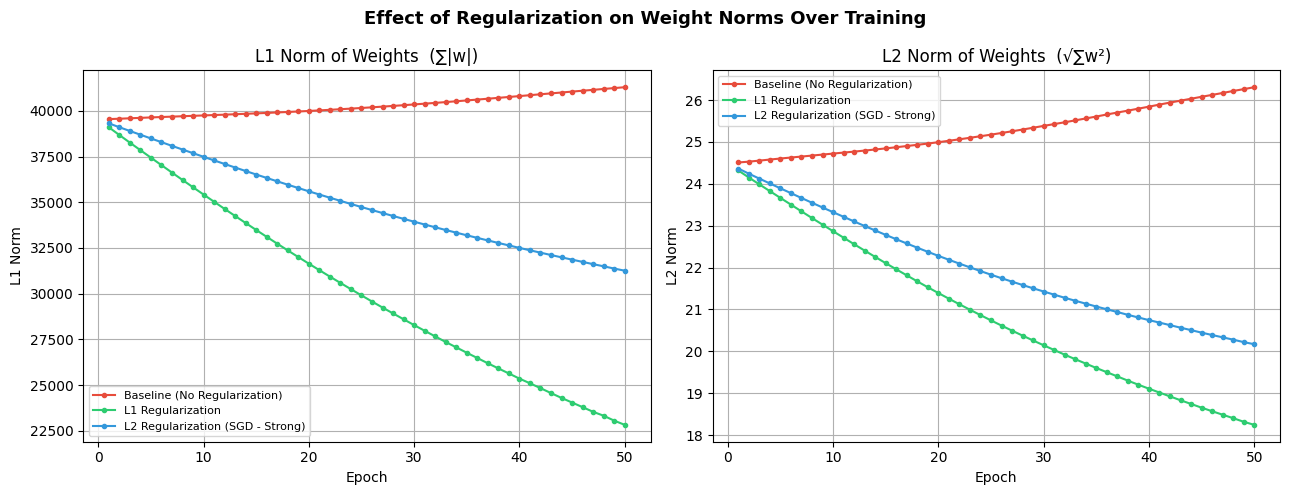

In [21]:
# ── Figure 2 — Weight norm evolution ─────────────────────────────────────────
fig2, axes2 = plt.subplots(1, 2, figsize=(13, 5))
fig2.suptitle("Effect of Regularization on Weight Norms Over Training", fontsize=13, fontweight='bold')

for r in all_results:
    c = COLORS[r["label"]]
    axes2[0].plot(epochs, r["l1_norms"], marker='o', color=c,
                  label=r["label"], linewidth=1.5, markersize=3)
    axes2[1].plot(epochs, r["l2_norms"], marker='o', color=c,
                  label=r["label"], linewidth=1.5, markersize=3)

axes2[0].set_title("L1 Norm of Weights  (∑|w|)")
axes2[0].set_xlabel("Epoch"); axes2[0].set_ylabel("L1 Norm")
axes2[0].legend(fontsize=8); axes2[0].grid(True)

axes2[1].set_title("L2 Norm of Weights  (√∑w²)")
axes2[1].set_xlabel("Epoch"); axes2[1].set_ylabel("L2 Norm")
axes2[1].legend(fontsize=8); axes2[1].grid(True)

plt.tight_layout()
plt.savefig("fig2_weight_norms.png", dpi=150, bbox_inches='tight')
plt.show()

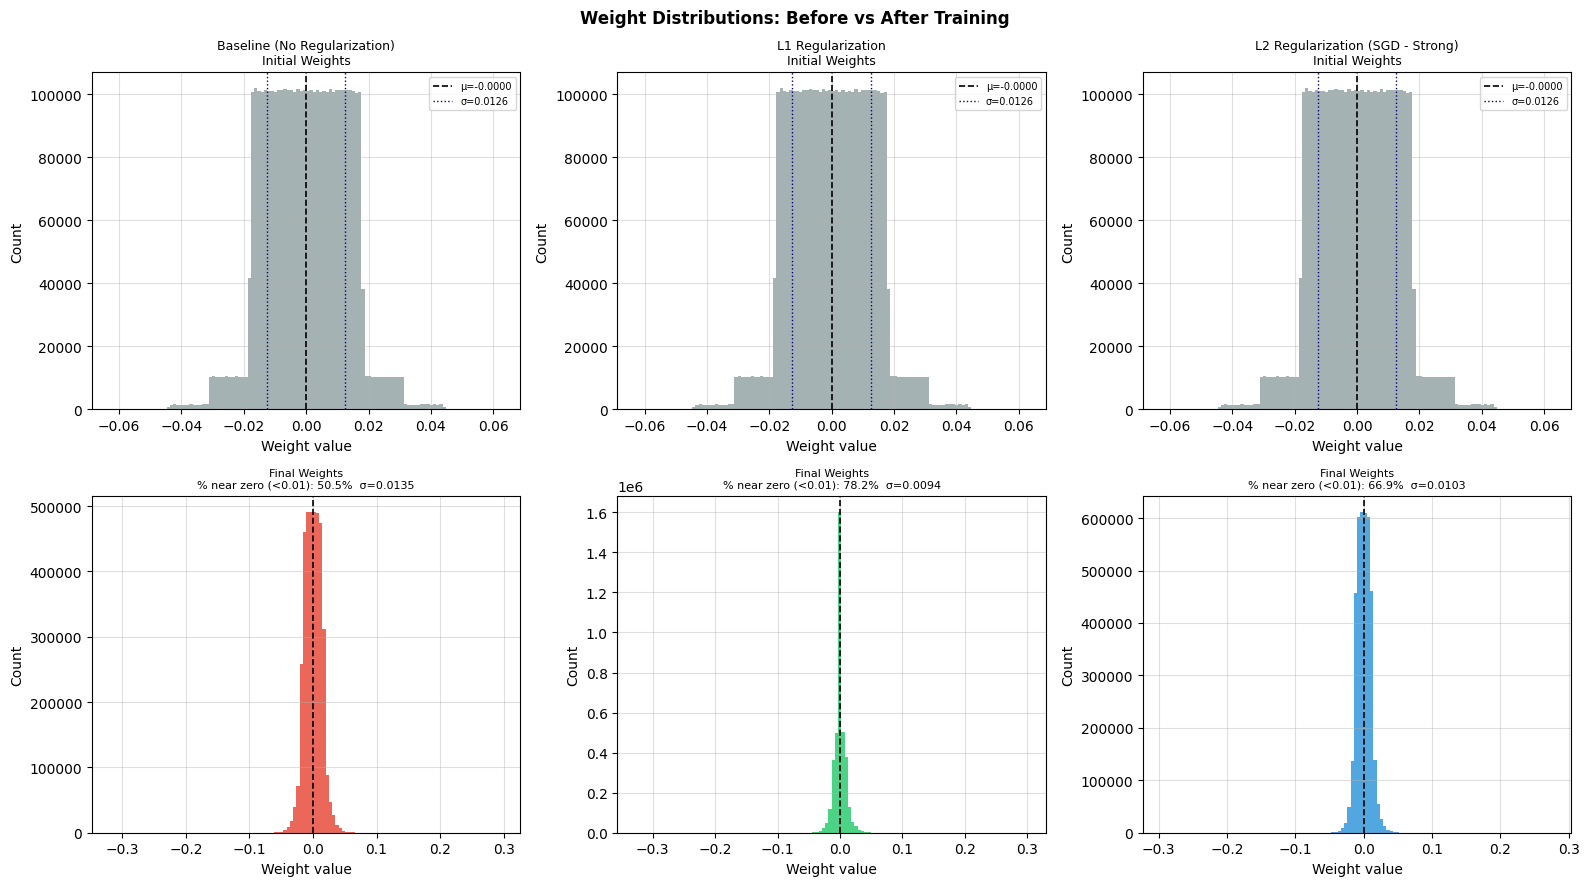

In [22]:
# ── Figure 3 — Weight histograms: initial vs final ────────────────────────────
fig3, axes3 = plt.subplots(2, 3, figsize=(16, 9))
fig3.suptitle("Weight Distributions: Before vs After Training", fontsize=12, fontweight='bold')

BINS = 120
for col, r in enumerate(all_results):
    c = COLORS[r["label"]]
    iw = r["initial_weights"]
    fw = r["final_weights"]

    # initial
    axes3[0, col].hist(iw, bins=BINS, color='#95a5a6', edgecolor='none', alpha=0.85)
    axes3[0, col].set_title(f"{r['label']}\nInitial Weights", fontsize=9)
    axes3[0, col].axvline(iw.mean(), color='black', linestyle='--', linewidth=1.2,
                           label=f'μ={iw.mean():.4f}')
    axes3[0, col].axvline(iw.mean()+iw.std(), color='navy', linestyle=':', linewidth=1,
                           label=f'σ={iw.std():.4f}')
    axes3[0, col].axvline(iw.mean()-iw.std(), color='navy', linestyle=':', linewidth=1)
    axes3[0, col].set_xlabel("Weight value"); axes3[0, col].set_ylabel("Count")
    axes3[0, col].legend(fontsize=7); axes3[0, col].grid(True, alpha=0.4)

    # final
    axes3[1, col].hist(fw, bins=BINS, color=c, edgecolor='none', alpha=0.85)
    axes3[1, col].set_title(
        f"Final Weights\n% near zero (<0.01): {100*(np.abs(fw)<0.01).mean():.1f}%  "
        f"σ={fw.std():.4f}", fontsize=8)
    axes3[1, col].axvline(fw.mean(), color='black', linestyle='--', linewidth=1.2)
    axes3[1, col].set_xlabel("Weight value"); axes3[1, col].set_ylabel("Count")
    axes3[1, col].grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig("fig3_weight_histograms.png", dpi=150, bbox_inches='tight')
plt.show()

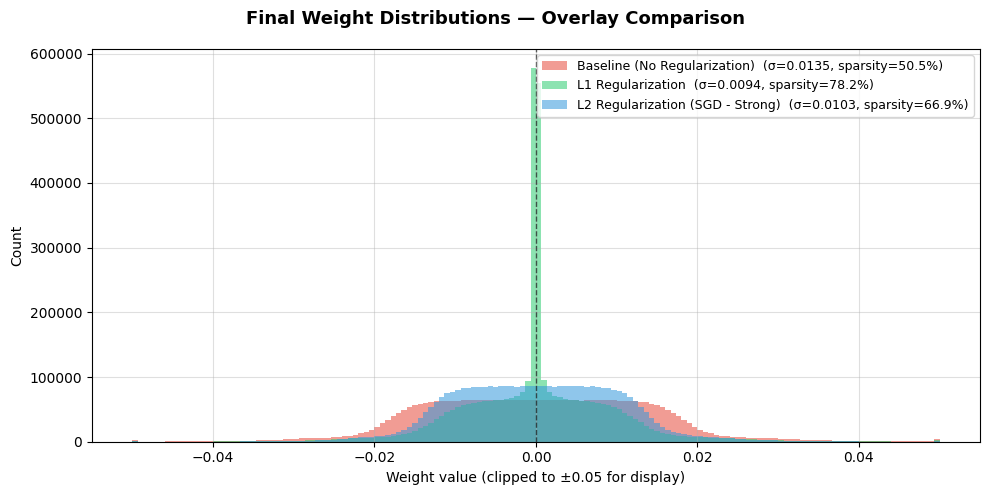

In [23]:
# ── Figure 4 — Final weight distribution overlay ──────────────────────────────
fig4, ax4 = plt.subplots(figsize=(10, 5))
fig4.suptitle("Final Weight Distributions — Overlay Comparison", fontsize=13, fontweight='bold')

for r in all_results:
    fw = r["final_weights"]
    clipped = np.clip(fw, -0.05, 0.05)
    ax4.hist(clipped, bins=150, alpha=0.55, color=COLORS[r["label"]],
             label=f'{r["label"]}  (σ={fw.std():.4f}, '
                   f'sparsity={100*(np.abs(fw)<0.01).mean():.1f}%)',
             edgecolor='none')

ax4.axvline(0, color='black', linewidth=1.0, linestyle='--', alpha=0.6)
ax4.set_xlabel("Weight value (clipped to ±0.05 for display)")
ax4.set_ylabel("Count")
ax4.legend(fontsize=9)
ax4.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig("fig4_weight_overlay.png", dpi=150, bbox_inches='tight')
plt.show()